In [1]:
# ============================================================
# CELL 1 — SETUP & LOAD ALL 21 DATASETS
# Must run this first — all cells below depend on these vars
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'sans-serif'
sns.set_theme(style='whitegrid')

# ── Folders ──────────────────────────────────────────────────
RAW_DIR   = '../data/raw'
CLEAN_DIR = '../data/clean'
OUT_DIR   = '../outputs'
for d in [CLEAN_DIR, OUT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Helper: safe CSV loader ──────────────────────────────────
def load(name, subdir=RAW_DIR):
    path = f'{subdir}/{name}.csv'
    if os.path.exists(path):
        df = pd.read_csv(path)
        return df
    else:
        print(f'  ⚠️  MISSING: {path}')
        print(f'      → Run 00_downloadDataFinal.ipynb first!')
        return None

print('Loading datasets...')
print('=' * 55)

# ── TEMA 1: The Ageing Nation ─────────────────────────────────
print('\n  📦  TEMA 1 — Demografi')
pop_malaysia    = load('population_malaysia')     # 1970–2024 | age × sex × ethnicity
pop_state       = load('population_state')        # 1970–2024 | by state
pop_district    = load('population_district')     # 2000–2024 | by district
fertility       = load('fertility')               # 1958–2023 | national TFR
fertility_state = load('fertility_state')         # ~1980–2023 | TFR by state
births          = load('births_annual')           # 2000–2023 | live births
deaths          = load('deaths')                  # 2000–2023 | deaths by sex
marriages       = load('marriages')               # 2017–2022 | marriages
hh_profile      = load('hh_profile')             # HIES cycles | HH composition

# ── TEMA 2: Income vs Inflation ──────────────────────────────
print('\n  📦  TEMA 2 — Kos Sara Hidup')
hh_income           = load('hh_income')           # 1970–2022 | national median/mean income
hh_income_state     = load('hh_income_state')     # 1970–2022 | income by state
hh_inequality       = load('hh_inequality')       # 1970–2022 | national Gini
hh_inequality_state = load('hh_inequality_state') # 1970–2022 | Gini by state
hh_poverty          = load('hh_poverty')          # 1970–2022 | national poverty rates
hh_poverty_state    = load('hh_poverty_state')    # 1970–2022 | poverty by state
hies_state          = load('hies_state')          # HIES cycles | expenditure by state
cpi_annual          = load('cpi_annual')          # 1970–2024 | annual CPI index
cpi_headline        = load('cpi_headline')        # 2010–2025 | monthly CPI index
cpi_inflation       = load('cpi_headline_inflation')  # 2010–2025 | monthly YoY inflation
cpi_state           = load('cpi_state')           # 2010–2025 | CPI by state
cpi_lowincome       = load('cpi_lowincome')       # 2010–2025 | CPI for low-income HH

# ── Count loaded ─────────────────────────────────────────────
all_vars = [
    pop_malaysia, pop_state, pop_district, fertility, fertility_state,
    births, deaths, marriages, hh_profile,
    hh_income, hh_income_state, hh_inequality, hh_inequality_state,
    hh_poverty, hh_poverty_state, hies_state, cpi_annual,
    cpi_headline, cpi_inflation, cpi_state, cpi_lowincome
]
loaded = sum(1 for df in all_vars if df is not None)
print(f'\n✅  {loaded}/21 datasets loaded successfully')
if loaded < 21:
    print(f'⚠️   {21-loaded} dataset(s) missing — check ../data/raw/ folder')
print()
print('👉  Run Cell 2 for shape check.')


Loading datasets...

  📦  TEMA 1 — Demografi

  📦  TEMA 2 — Kos Sara Hidup

✅  21/21 datasets loaded successfully

👉  Run Cell 2 for shape check.


In [2]:
# ============================================================
# CELL 2 — SHAPE CHECK
# Confirm all 21 datasets loaded correctly
# ============================================================

all_ds = [
    ('── TEMA 1 — DEMOGRAFI ──────────────────────────────────────', None),
    ('population_malaysia',    pop_malaysia),
    ('population_state',       pop_state),
    ('population_district',    pop_district),
    ('fertility',              fertility),
    ('fertility_state',        fertility_state),
    ('births_annual',          births),
    ('deaths',                 deaths),
    ('marriages',              marriages),
    ('hh_profile',             hh_profile),
    ('── TEMA 2 — KOS SARA HIDUP ─────────────────────────────────', None),
    ('hh_income',              hh_income),
    ('hh_income_state',        hh_income_state),
    ('hh_inequality',          hh_inequality),
    ('hh_inequality_state',    hh_inequality_state),
    ('hh_poverty',             hh_poverty),
    ('hh_poverty_state',       hh_poverty_state),
    ('hies_state',             hies_state),
    ('cpi_annual',             cpi_annual),
    ('cpi_headline',           cpi_headline),
    ('cpi_headline_inflation', cpi_inflation),
    ('cpi_state',              cpi_state),
    ('cpi_lowincome',          cpi_lowincome),
]

print(f'  {"DATASET":<32} {"ROWS":>7}  {"COLS":>4}  COLUMNS')
print('─' * 100)

ok_count   = 0
fail_count = 0

for name, df in all_ds:
    if df is None and name.startswith('──'):
        print(f'\n{name}')
        continue
    if df is None:
        print(f'  ❌  {name:<32} MISSING — rerun 00_downloadDataFinal.ipynb')
        fail_count += 1
        continue
    cols_str = ', '.join(df.columns[:6])
    if len(df.columns) > 6:
        cols_str += f' (+{len(df.columns)-6} more)'
    print(f'  ✅  {name:<32} {df.shape[0]:>7,}  {df.shape[1]:>4}  {cols_str}')
    ok_count += 1

print('─' * 100)
print(f'  ✅ OK: {ok_count}   ❌ Missing: {fail_count}')
print()
print('👉  Run Cell 3 for null/missing value check.')


  DATASET                             ROWS  COLS  COLUMNS
────────────────────────────────────────────────────────────────────────────────────────────────────

── TEMA 1 — DEMOGRAFI ──────────────────────────────────────
  ✅  population_malaysia               92,000     5  age, sex, date, ethnicity, population
  ✅  population_state                 1,807,000     6  age, sex, date, state, ethnicity, population
  ✅  population_district              10,567,000     7  age, sex, date, state, district, ethnicity (+1 more)
  ✅  fertility                            528     3  date, age_group, fertility_rate
  ✅  fertility_state                  2,280,000     4  date, state, age_group, fertility_rate
  ✅  births_annual                         24     3  abs, date, rate
  ✅  deaths                                24     3  abs, date, rate
  ✅  marriages                             12     4  abs, sex, date, rate
  ✅  hh_profile                            19     3  date, households, living_quarters



In [3]:
# ============================================================
# CELL 3 — NULL / MISSING VALUE CHECK
# OpenDOSM data is generally clean, but always verify!
# ============================================================

print('Checking for missing values across all 21 datasets...\n')
print(f'  {"DATASET":<32}  {"TOTAL MISSING":>14}  DETAIL')
print('─' * 80)

has_missing = []

for name, df in all_ds:
    if df is None:
        continue
    if name.startswith('──'):
        continue

    missing_per_col = df.isnull().sum()
    total_missing   = missing_per_col.sum()

    if total_missing == 0:
        print(f'  ✅  {name:<32}  {"0":>14}  Clean')
    else:
        detail = {col: int(cnt) for col, cnt in missing_per_col.items() if cnt > 0}
        pct    = (total_missing / (df.shape[0] * df.shape[1])) * 100
        print(f'  ⚠️   {name:<32}  {total_missing:>14,}  ({pct:.1f}%)  {detail}')
        has_missing.append(name)

print('─' * 80)
if len(has_missing) == 0:
    print('  🎉  ALL datasets are clean — no missing values!')
else:
    print(f'  ⚠️   {len(has_missing)} dataset(s) have missing values: {has_missing}')
    print()
    print('  NOTE: Some missing values are expected (e.g. hardcore poverty only')
    print('  tracked from a certain year). These are handled in Cell 7 (cleaning).')

print()
print('👉  Run Cell 4 for date standardisation.')


Checking for missing values across all 21 datasets...

  DATASET                            TOTAL MISSING  DETAIL
────────────────────────────────────────────────────────────────────────────────
  ✅  population_malaysia                            0  Clean
  ✅  population_state                               0  Clean
  ✅  population_district                            0  Clean
  ✅  fertility                                      0  Clean
  ✅  fertility_state                                0  Clean
  ✅  births_annual                                  0  Clean
  ✅  deaths                                         0  Clean
  ✅  marriages                                      0  Clean
  ✅  hh_profile                                     0  Clean
  ✅  hh_income                                      0  Clean
  ⚠️   hh_income_state                               11  (0.9%)  {'income_median': 11}
  ✅  hh_inequality                                  0  Clean
  ✅  hh_inequality_state                       

In [5]:
# ============================================================
# CELL 4 — DATE STANDARDISATION
# Extract 'year' from 'date' column where needed
# Datasets that already have 'year': pop_malaysia, hh_income, etc.
# Datasets that have 'date' (YYYY-MM-DD): cpi_headline, cpi_inflation, etc.
# ============================================================

date_datasets = {
    'pop_malaysia'        : pop_malaysia,
    'pop_state'           : pop_state,
    'pop_district'        : pop_district,
    'fertility'           : fertility,
    'fertility_state'     : fertility_state,
    'births'              : births,
    'deaths'              : deaths,
    'marriages'           : marriages,
    'hh_profile'          : hh_profile,
    'hh_income'           : hh_income,
    'hh_income_state'     : hh_income_state,
    'hh_inequality'       : hh_inequality,
    'hh_inequality_state' : hh_inequality_state,
    'hh_poverty'          : hh_poverty,
    'hh_poverty_state'    : hh_poverty_state,
    'hies_state'          : hies_state,
    'cpi_annual'          : cpi_annual,
    'cpi_headline'        : cpi_headline,
    'cpi_inflation'       : cpi_inflation,
    'cpi_state'           : cpi_state,
    'cpi_lowincome'       : cpi_lowincome,
}

print(f'  {"DATASET":<32}  {"DATE COL":>10}  {"YEAR COL":>9}  YEAR RANGE')
print('─' * 72)

for name, df in date_datasets.items():
    if df is None:
        continue

    # Case 1: Already has 'year' column
    if 'year' in df.columns:
        yr_min = int(df['year'].min())
        yr_max = int(df['year'].max())
        print(f'  ✅  {name:<32}  {"—":>10}  {"year ✓":>9}  {yr_min}–{yr_max}')

    # Case 2: Has 'date' column → extract year
    elif 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df['year'] = df['date'].dt.year
        yr_min = int(df['year'].min())
        yr_max = int(df['year'].max())
        print(f'  🔧  {name:<32}  {"date":>10}  {"year ✓":>9}  {yr_min}–{yr_max}  ← extracted')

    else:
        print(f'  ⚠️   {name:<32}  {"none":>10}  {"—":>9}  No date/year column found')

print()
print('✅  Date standardisation complete!')
print('👉  Run Cell 5 for year-range summary table.')


  DATASET                             DATE COL   YEAR COL  YEAR RANGE
────────────────────────────────────────────────────────────────────────
  ✅  pop_malaysia                               —     year ✓  1970–1981
  ✅  pop_state                                  —     year ✓  2020–2020
  ✅  pop_district                               —     year ✓  2020–2021
  ✅  fertility                                  —     year ✓  1958–2023
  ✅  fertility_state                            —     year ✓  2001–2023
  ✅  births                                     —     year ✓  2000–2023
  ✅  deaths                                     —     year ✓  2000–2023
  ✅  marriages                                  —     year ✓  2017–2022
  ✅  hh_profile                                 —     year ✓  1970–2024
  ✅  hh_income                                  —     year ✓  1970–2022
  ✅  hh_income_state                            —     year ✓  1970–2022
  ✅  hh_inequality                              —     year ✓  197

In [6]:
# ============================================================
# CELL 5 — YEAR RANGE SUMMARY TABLE
# Reference: what years are available per dataset?
# ============================================================

print('=' * 85)
print(f'  {"DATASET":<32}  {"TEMA":<8}  {"ROWS":>7}  {"YEAR RANGE":<16}  {"FREQUENCY"}')
print('  ' + '─' * 81)

summary_data = [
    # (varname, df, tema, frequency_note)
    ('population_malaysia',    pop_malaysia,        'Tema 1', 'Annual (estimates)'),
    ('population_state',       pop_state,           'Tema 1', 'Annual (estimates)'),
    ('population_district',    pop_district,        'Tema 1', 'Annual (estimates)'),
    ('fertility',              fertility,           'Tema 1', 'Annual'),
    ('fertility_state',        fertility_state,     'Tema 1', 'Annual'),
    ('births_annual',          births,              'Tema 1', 'Annual'),
    ('deaths',                 deaths,              'Tema 1', 'Annual'),
    ('marriages',              marriages,           'Tema 1', 'Annual'),
    ('hh_profile',             hh_profile,          'Tema 1', 'HIES survey cycle'),
    ('hh_income',              hh_income,           'Tema 2', 'HIES survey cycle'),
    ('hh_income_state',        hh_income_state,     'Tema 2', 'HIES survey cycle'),
    ('hh_inequality',          hh_inequality,       'Tema 2', 'HIES survey cycle'),
    ('hh_inequality_state',    hh_inequality_state, 'Tema 2', 'HIES survey cycle'),
    ('hh_poverty',             hh_poverty,          'Tema 2', 'HIES survey cycle'),
    ('hh_poverty_state',       hh_poverty_state,    'Tema 2', 'HIES survey cycle'),
    ('hies_state',             hies_state,          'Tema 2', 'HIES survey cycle'),
    ('cpi_annual',             cpi_annual,          'Tema 2', 'Annual'),
    ('cpi_headline',           cpi_headline,        'Tema 2', 'Monthly'),
    ('cpi_headline_inflation', cpi_inflation,       'Tema 2', 'Monthly'),
    ('cpi_state',              cpi_state,           'Tema 2', 'Monthly'),
    ('cpi_lowincome',          cpi_lowincome,       'Tema 2', 'Monthly'),
]

last_tema = ''
for name, df, tema, freq in summary_data:
    if tema != last_tema:
        print()
        last_tema = tema

    if df is None:
        print(f'  ❌  {name:<32}  {tema:<8}  {"MISSING":>7}')
        continue

    yr_col = 'year' if 'year' in df.columns else None
    if yr_col:
        yr_min = int(df[yr_col].min())
        yr_max = int(df[yr_col].max())
        yr_range = f'{yr_min}–{yr_max}'
        span     = yr_max - yr_min
    else:
        yr_range = 'N/A'
        span     = 0

    print(f'  ✅  {name:<32}  {tema:<8}  {len(df):>7,}  {yr_range:<16}  {freq}')

print()
print('=' * 85)
print()
print('📌 KEY NOTES:')
print('   • HIES surveys: conducted every 2–3 years (not annual)')
print('   • CPI headline/inflation: monthly data — use groupby(year).mean() for annual')
print('   • population_district: starts 2000 (not 1970)')
print('   • Overlap for combined analysis (HIES + CPI): 2010–2022')
print()
print('👉  Run Cell 6 for deep-dive structure checks.')


  DATASET                           TEMA         ROWS  YEAR RANGE        FREQUENCY
  ─────────────────────────────────────────────────────────────────────────────────

  ✅  population_malaysia               Tema 1     92,000  1970–1981         Annual (estimates)
  ✅  population_state                  Tema 1    1,807,000  2020–2020         Annual (estimates)
  ✅  population_district               Tema 1    10,567,000  2020–2021         Annual (estimates)
  ✅  fertility                         Tema 1        528  1958–2023         Annual
  ✅  fertility_state                   Tema 1    2,280,000  2001–2023         Annual
  ✅  births_annual                     Tema 1         24  2000–2023         Annual
  ✅  deaths                            Tema 1         24  2000–2023         Annual
  ✅  marriages                         Tema 1         12  2017–2022         Annual
  ✅  hh_profile                        Tema 1         19  1970–2024         HIES survey cycle

  ✅  hh_income                

In [7]:
# ============================================================
# CELL 6A — POPULATION MALAYSIA (most complex dataset)
# This drives: pyramid chart, ageing index, dependency ratio
# ============================================================

if pop_malaysia is not None:
    print('── population_malaysia ──────────────────────────────')
    print(f'  Shape      : {pop_malaysia.shape[0]:,} rows × {pop_malaysia.shape[1]} cols')
    print(f'  Columns    : {list(pop_malaysia.columns)}')
    print(f'  Year range : {pop_malaysia["year"].min()} – {pop_malaysia["year"].max()}')
    print(f'  Age groups : {sorted(pop_malaysia["age"].unique())}')
    print(f'  Sex values : {pop_malaysia["sex"].unique().tolist()}')
    print(f'  Ethnicity  : {pop_malaysia["ethnicity"].unique().tolist()}')
    print()

    # Extract overall population for quick sanity check
    pop_total = pop_malaysia[
        (pop_malaysia['age']       == 'overall') &
        (pop_malaysia['sex']       == 'both') &
        (pop_malaysia['ethnicity'] == 'overall')
    ].sort_values('year')

    first = pop_total.iloc[0]
    last  = pop_total.iloc[-1]
    growth_pct = ((last['population'] / first['population']) - 1) * 100

    print(f'  📌 INSIGHT:')
    print(f'     Population {int(first["year"])}: {first["population"]:,.0f}k')
    print(f'     Population {int(last["year"])}:  {last["population"]:,.0f}k')
    print(f'     Growth: +{growth_pct:.0f}% over {int(last["year"])-int(first["year"])} years')
    print()
    display(pop_malaysia[
        (pop_malaysia['sex']       == 'both') &
        (pop_malaysia['ethnicity'] == 'overall')
    ].head(8))


── population_malaysia ──────────────────────────────
  Shape      : 92,000 rows × 6 cols
  Columns    : ['age', 'sex', 'date', 'ethnicity', 'population', 'year']
  Year range : 1970 – 1981
  Age groups : ['0-4', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '5-9', '50-54', '55-59', '60-64', '65-69', '70+', '70-74', '75-79', '80+', 'overall']
  Sex values : ['both', 'female', 'male']
  Ethnicity  : ['overall', 'bumi', 'chinese', 'indian', 'other']

  📌 INSIGHT:
     Population 1970: 10,882k
     Population 1981:  14,257k
     Growth: +31% over 11 years



,age,sex,date,ethnicity,population,year
0,overall,both,1970-01-01,overall,10881.8,1970
1,0-4,both,1970-01-01,overall,1702.4,1970
2,5-9,both,1970-01-01,overall,1690.3,1970
3,10-14,both,1970-01-01,overall,1454.7,1970
4,15-19,both,1970-01-01,overall,1197.6,1970
5,20-24,both,1970-01-01,overall,921.6,1970
6,25-29,both,1970-01-01,overall,692.5,1970
7,30-34,both,1970-01-01,overall,659.1,1970


In [8]:
# ============================================================
# CELL 6B — FERTILITY + BIRTHS + DEATHS + MARRIAGES
# ============================================================

if fertility is not None:
    print('── fertility ────────────────────────────────────────')
    print(f'  Columns    : {list(fertility.columns)}')
    print(f'  Age groups : {fertility["age_group"].unique().tolist()}')
    print(f'  Year range : {fertility["year"].min()} – {fertility["year"].max()}')
    tfr_rows = fertility[fertility['age_group'] == 'tfr']
    if len(tfr_rows) > 0:
        latest = tfr_rows.sort_values('year').iloc[-1]
        print(f'  Latest TFR : {latest["fertility_rate"]:.2f} ({int(latest["year"])})')
        if latest['fertility_rate'] < 2.1:
            print(f'  📌 INSIGHT: TFR below replacement level 2.1 — ageing nation signal!')
    display(fertility.head(5))
    print()

if births is not None:
    print('── births_annual ────────────────────────────────────')
    print(f'  Columns    : {list(births.columns)}')
    print(f'  Year range : {births["year"].min()} – {births["year"].max()}')
    display(births.head(3))
    print()

if deaths is not None:
    print('── deaths ───────────────────────────────────────────')
    print(f'  Columns    : {list(deaths.columns)}')
    print(f'  Year range : {deaths["year"].min()} – {deaths["year"].max()}')
    display(deaths.head(3))
    print()

if marriages is not None:
    print('── marriages ────────────────────────────────────────')
    print(f'  Columns    : {list(marriages.columns)}')
    print(f'  Year range : {marriages["year"].min()} – {marriages["year"].max()}')
    if 'sex' in marriages.columns:
        print(f'  Sex filter : {marriages["sex"].unique().tolist()}  ← use sex=="both" for totals')
    display(marriages.head(3))


── fertility ────────────────────────────────────────
  Columns    : ['date', 'age_group', 'fertility_rate', 'year']
  Age groups : ['tfr', '15–19', '20–24', '25–29', '30–34', '35–39', '40–44', '45–49']
  Year range : 1958 – 2023
  Latest TFR : 1.73 (2023)
  📌 INSIGHT: TFR below replacement level 2.1 — ageing nation signal!


,date,age_group,fertility_rate,year
0,1958-01-01,tfr,6.28,1958
1,1959-01-01,tfr,6.18,1959
2,1960-01-01,tfr,6.04,1960
3,1961-01-01,tfr,6.20,1961
4,1962-01-01,tfr,6.04,1962



── births_annual ────────────────────────────────────
  Columns    : ['abs', 'date', 'rate', 'year']
  Year range : 2000 – 2023


,abs,date,rate,year
0,537853,2000-01-01,22.9,2000
1,505479,2001-01-01,21.0,2001
2,494538,2002-01-01,20.2,2002



── deaths ───────────────────────────────────────────
  Columns    : ['abs', 'date', 'rate', 'year']
  Year range : 2000 – 2023


,abs,date,rate,year
0,100707,2000-01-01,4.3,2000
1,104531,2001-01-01,4.3,2001
2,110367,2002-01-01,4.5,2002



── marriages ────────────────────────────────────────
  Columns    : ['abs', 'sex', 'date', 'rate', 'year']
  Year range : 2017 – 2022
  Sex filter : ['female', 'male']  ← use sex=="both" for totals


,abs,sex,date,rate,year
0,203741,female,2017-01-01,24.48,2017
1,203741,male,2017-01-01,23.03,2017
2,206352,female,2018-01-01,24.70,2018


In [9]:
# ============================================================
# CELL 6C — HOUSEHOLD INCOME + CPI (Tema 2 key datasets)
# ============================================================

if hh_income is not None:
    print('── hh_income ────────────────────────────────────────')
    print(f'  Columns    : {list(hh_income.columns)}')
    print(f'  Year range : {hh_income["year"].min()} – {hh_income["year"].max()}')
    print(f'  Survey yrs : {sorted(hh_income["year"].unique().tolist())}')
    print(f'  📌 NOTE: HIES survey every 2–3 years — gaps are normal!')
    display(hh_income)
    print()

if hh_income_state is not None:
    print('── hh_income_state ──────────────────────────────────')
    print(f'  Columns    : {list(hh_income_state.columns)}')
    print(f'  States     : {sorted(hh_income_state["state"].unique().tolist())}')
    print(f'  Year range : {hh_income_state["year"].min()} – {hh_income_state["year"].max()}')
    display(hh_income_state.head(6))
    print()

if cpi_inflation is not None:
    print('── cpi_headline_inflation ───────────────────────────')
    print(f'  Columns    : {list(cpi_inflation.columns)}')
    print(f'  Year range : {cpi_inflation["year"].min()} – {cpi_inflation["year"].max()}')
    if 'division' in cpi_inflation.columns:
        print(f'  Divisions  : {sorted(cpi_inflation["division"].unique().tolist())}')
        print(f'  📌 NOTE: "overall" = headline CPI. Use for income vs inflation chart.')
    display(cpi_inflation.head(6))


── hh_income ────────────────────────────────────────
  Columns    : ['date', 'income_mean', 'income_median', 'year']
  Year range : 1970 – 2022
  Survey yrs : [1970, 1974, 1976, 1979, 1984, 1987, 1989, 1992, 1995, 1997, 1999, 2002, 2004, 2007, 2009, 2012, 2014, 2016, 2019, 2020, 2022]
  📌 NOTE: HIES survey every 2–3 years — gaps are normal!


,date,income_mean,income_median,year
0,1970-01-01,264,166,1970
1,1974-01-01,362,227,1974
2,1976-01-01,505,308,1976
3,1979-01-01,678,429,1979
4,1984-01-01,1098,719,1984
5,1987-01-01,1083,738,1987
6,1989-01-01,1169,816,1989
7,1992-01-01,1566,1077,1992
8,1995-01-01,2020,1377,1995
9,1997-01-01,2606,1724,1997



── hh_income_state ──────────────────────────────────
  Columns    : ['date', 'state', 'income_mean', 'income_median', 'year']
  States     : ['Johor', 'Kedah', 'Kelantan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya']
  Year range : 1970 – 2022


,date,state,income_mean,income_median,year
0,1970-01-01,Johor,237,NaN,1970
1,1974-01-01,Johor,382,269.0,1974
2,1976-01-01,Johor,513,370.0,1976
3,1979-01-01,Johor,731,518.0,1979
4,1984-01-01,Johor,1065,793.0,1984
5,1987-01-01,Johor,1060,816.0,1987



── cpi_headline_inflation ───────────────────────────
  Columns    : ['date', 'division', 'inflation_mom', 'inflation_yoy', 'year']
  Year range : 2000 – 2026
  Divisions  : ['01', '02', '13', 'overall']
  📌 NOTE: "overall" = headline CPI. Use for income vs inflation chart.


,date,division,inflation_mom,inflation_yoy,year
0,2011-11-01,13,0.4,3.2,2011
1,2011-12-01,13,0.0,3.1,2011
2,2012-01-01,13,-0.1,2.7,2012
3,2012-02-01,13,0.4,3.2,2012
4,2012-03-01,13,-0.1,2.9,2012
5,2012-04-01,13,-0.2,2.6,2012


In [10]:
# ============================================================
# CELL 6D — INEQUALITY + POVERTY + HIES
# ============================================================

if hh_inequality is not None:
    print('── hh_inequality (National Gini) ────────────────────')
    print(f'  Columns    : {list(hh_inequality.columns)}')
    print(f'  Year range : {hh_inequality["year"].min()} – {hh_inequality["year"].max()}')
    print(f'  Gini range : {hh_inequality["gini"].min():.3f} – {hh_inequality["gini"].max():.3f}')
    gini_first = hh_inequality.sort_values('year').iloc[0]
    gini_last  = hh_inequality.sort_values('year').iloc[-1]
    direction  = '📉 Improved (decreased)' if gini_last['gini'] < gini_first['gini'] else '📈 Worsened (increased)'
    print(f'  📌 INSIGHT: Gini {int(gini_first["year"])}: {gini_first["gini"]:.3f} → {int(gini_last["year"])}: {gini_last["gini"]:.3f}  {direction}')
    display(hh_inequality)
    print()

if hh_inequality_state is not None:
    print('── hh_inequality_state ──────────────────────────────')
    print(f'  States     : {sorted(hh_inequality_state["state"].unique().tolist())}')
    latest_yr = hh_inequality_state['year'].max()
    latest    = hh_inequality_state[hh_inequality_state['year'] == latest_yr].sort_values('gini', ascending=False)
    print(f'  Most unequal state ({int(latest_yr)}): {latest.iloc[0]["state"]} (Gini = {latest.iloc[0]["gini"]:.3f})')
    print(f'  Most equal state   ({int(latest_yr)}): {latest.iloc[-1]["state"]} (Gini = {latest.iloc[-1]["gini"]:.3f})')
    display(hh_inequality_state.head(8))
    print()

if hh_poverty is not None:
    print('── hh_poverty ───────────────────────────────────────')
    print(f'  Columns    : {list(hh_poverty.columns)}')
    print(f'  Year range : {hh_poverty["year"].min()} – {hh_poverty["year"].max()}')
    pov_first = hh_poverty.sort_values('year').iloc[0]
    pov_last  = hh_poverty.sort_values('year').iloc[-1]
    drop      = pov_first['poverty_absolute'] - pov_last['poverty_absolute']
    print(f'  📌 INSIGHT: Poverty dropped {pov_first["poverty_absolute"]:.1f}% → {pov_last["poverty_absolute"]:.1f}% ({drop:.1f}pp reduction!)')
    display(hh_poverty)


── hh_inequality (National Gini) ────────────────────
  Columns    : ['date', 'gini', 'year']
  Year range : 1970 – 2022
  Gini range : 0.399 – 0.557
  📌 INSIGHT: Gini 1970: 0.513 → 2022: 0.404  📉 Improved (decreased)


,date,gini,year
0,1970-01-01,0.513,1970
1,1974-01-01,0.530,1974
2,1976-01-01,0.557,1976
3,1979-01-01,0.505,1979
4,1984-01-01,0.483,1984
5,1987-01-01,0.456,1987
6,1989-01-01,0.442,1989
7,1992-01-01,0.451,1992
8,1995-01-01,0.456,1995
9,1997-01-01,0.459,1997



── hh_inequality_state ──────────────────────────────
  States     : ['Johor', 'Kedah', 'Kelantan', 'Melaka', 'Negeri Sembilan', 'Pahang', 'Perak', 'Perlis', 'Pulau Pinang', 'Sabah', 'Sarawak', 'Selangor', 'Terengganu', 'W.P. Kuala Lumpur', 'W.P. Labuan', 'W.P. Putrajaya']
  Most unequal state (2022): Sabah (Gini = 0.395)
  Most equal state   (2022): W.P. Labuan (Gini = 0.300)


,date,gini,state,year
0,1974-01-01,0.439,Johor,1974
1,1976-01-01,0.469,Johor,1976
2,1979-01-01,0.442,Johor,1979
3,1984-01-01,0.404,Johor,1984
4,1987-01-01,0.386,Johor,1987
5,1989-01-01,0.381,Johor,1989
6,1992-01-01,0.423,Johor,1992
7,1995-01-01,0.399,Johor,1995



── hh_poverty ───────────────────────────────────────
  Columns    : ['date', 'poverty_absolute', 'poverty_hardcore', 'poverty_relative', 'year']
  Year range : 1970 – 2022
  📌 INSIGHT: Poverty dropped 49.3% → 6.2% (43.1pp reduction!)


,date,poverty_absolute,poverty_hardcore,poverty_relative,year
0,1970-01-01,49.3,NaN,NaN,1970
1,1976-01-01,37.7,NaN,NaN,1976
2,1979-01-01,37.4,NaN,NaN,1979
3,1984-01-01,20.7,6.9,NaN,1984
4,1987-01-01,19.4,5.1,NaN,1987
5,1989-01-01,16.5,3.9,NaN,1989
6,1992-01-01,12.4,2.9,NaN,1992
7,1995-01-01,8.7,2.0,19.5,1995
8,1997-01-01,6.1,1.4,19.7,1997
9,1999-01-01,7.5,1.4,19.0,1999


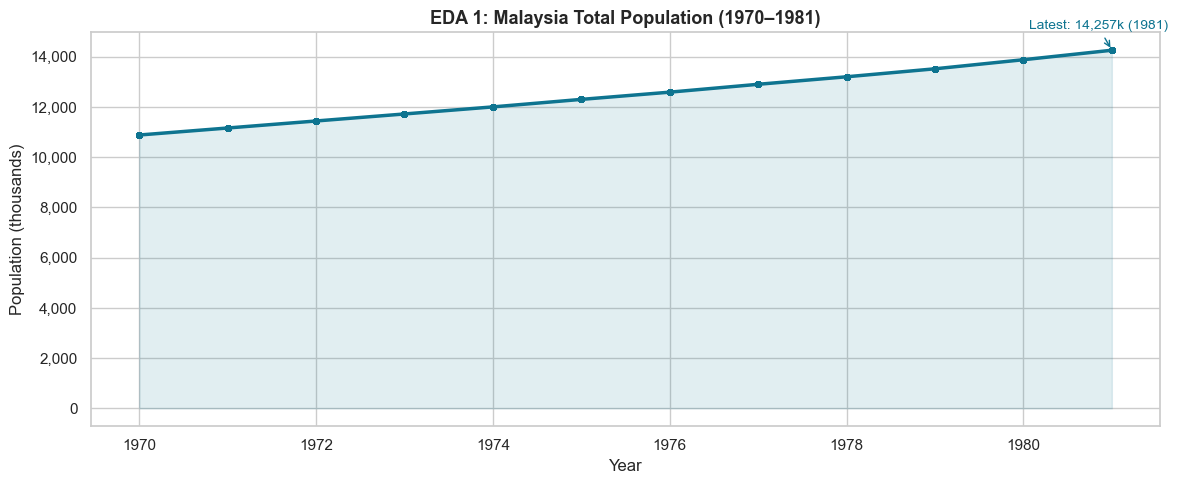

✅  Saved: outputs/eda01_population_growth.png


In [11]:
# ============================================================
# CELL 7A — EDA CHART 1: Total Population Growth
# ============================================================

if pop_malaysia is not None:
    pop_total = pop_malaysia[
        (pop_malaysia['age']       == 'overall') &
        (pop_malaysia['sex']       == 'both') &
        (pop_malaysia['ethnicity'] == 'overall')
    ].copy().sort_values('year')

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(pop_total['year'], pop_total['population'],
            color='#0E7490', linewidth=2.5, marker='o', markersize=4)
    ax.fill_between(pop_total['year'], pop_total['population'],
                    alpha=0.12, color='#0E7490')
    ax.set_title(f'EDA 1: Malaysia Total Population ({int(pop_total["year"].min())}–{int(pop_total["year"].max())})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Population (thousands)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.annotate(f'Latest: {pop_total.iloc[-1]["population"]:,.0f}k ({int(pop_total.iloc[-1]["year"])})',
                xy=(pop_total.iloc[-1]['year'], pop_total.iloc[-1]['population']),
                xytext=(-60, 15), textcoords='offset points',
                fontsize=10, color='#0E7490',
                arrowprops=dict(arrowstyle='->', color='#0E7490'))
    plt.tight_layout()
    plt.savefig('../outputs/eda01_population_growth.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅  Saved: outputs/eda01_population_growth.png')


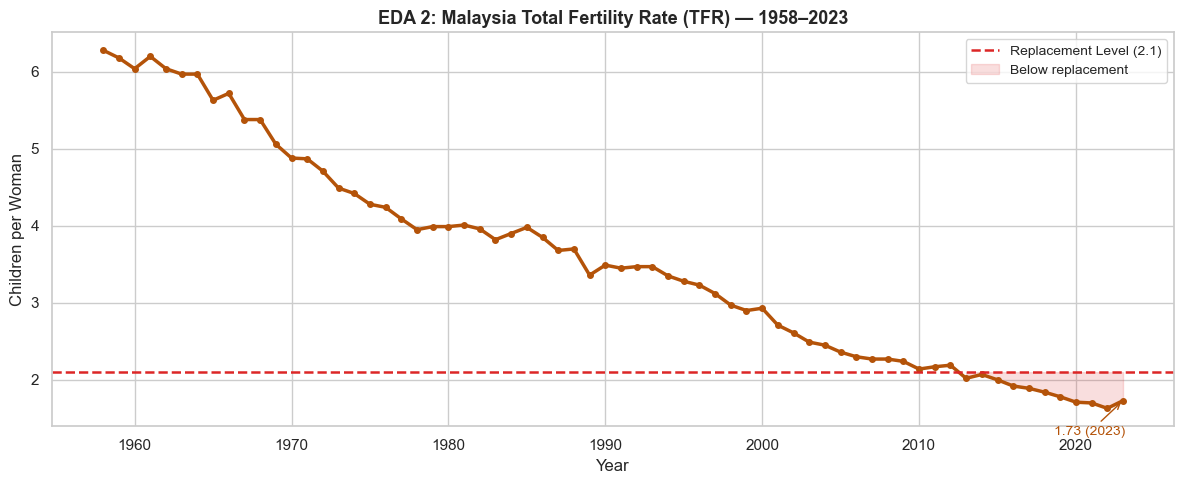

✅  Saved: outputs/eda02_fertility_rate.png
📌  Latest TFR: 1.73 (2023) —  ⚠️  BELOW 2.1!


In [12]:
# ============================================================
# CELL 7B — EDA CHART 2: Fertility Rate Trend (TFR)
# ============================================================

if fertility is not None:
    tfr = fertility[fertility['age_group'] == 'tfr'].copy().sort_values('year')
    if len(tfr) == 0:
        tfr = fertility.groupby('year')['fertility_rate'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(tfr['year'], tfr['fertility_rate'],
            color='#B45309', linewidth=2.5, marker='o', markersize=4)
    ax.axhline(y=2.1, color='#DC2626', linestyle='--', linewidth=1.8,
               label='Replacement Level (2.1)')
    ax.fill_between(tfr['year'], tfr['fertility_rate'], 2.1,
                    where=tfr['fertility_rate'] < 2.1,
                    alpha=0.15, color='#DC2626', label='Below replacement')
    ax.set_title(f'EDA 2: Malaysia Total Fertility Rate (TFR) — {int(tfr["year"].min())}–{int(tfr["year"].max())}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Children per Woman')
    ax.legend(fontsize=10)
    latest = tfr.iloc[-1]
    ax.annotate(f'{latest["fertility_rate"]:.2f} ({int(latest["year"])})',
                xy=(latest['year'], latest['fertility_rate']),
                xytext=(-50, -25), textcoords='offset points',
                fontsize=10, color='#B45309',
                arrowprops=dict(arrowstyle='->', color='#B45309'))
    plt.tight_layout()
    plt.savefig('../outputs/eda02_fertility_rate.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅  Saved: outputs/eda02_fertility_rate.png')
    print(f'📌  Latest TFR: {latest["fertility_rate"]:.2f} ({int(latest["year"])}) — ',
          '⚠️  BELOW 2.1!' if latest['fertility_rate'] < 2.1 else '✅ Above 2.1')


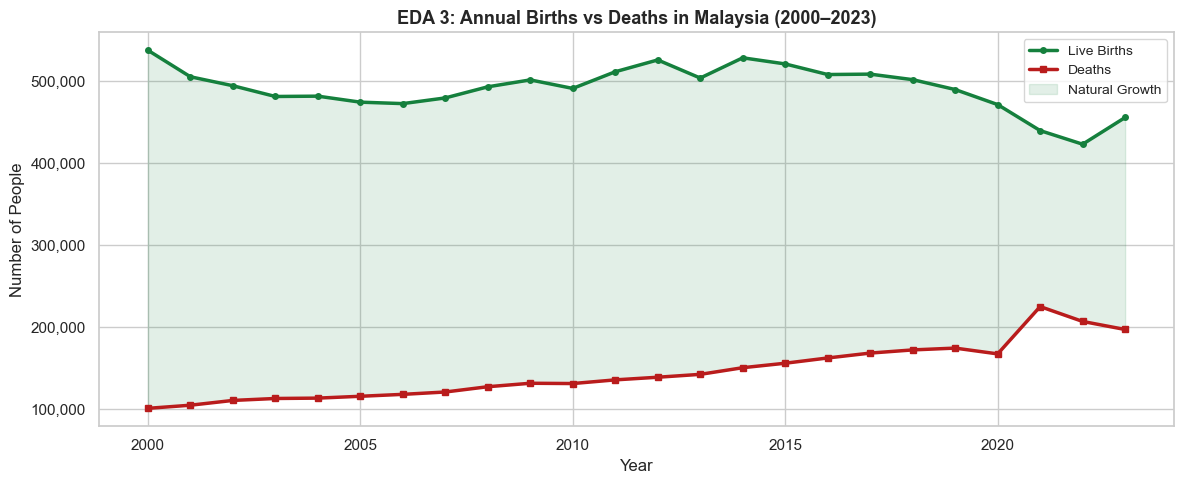

✅  Saved: outputs/eda03_births_vs_deaths.png


In [13]:
# ============================================================
# CELL 7C — EDA CHART 3: Births vs Deaths
# ============================================================

if births is not None and deaths is not None:
    b = births.sort_values('year')
    d = deaths.sort_values('year')

    # Filter to matching years
    b_all = b[b['sex'] == 'both'] if 'sex' in b.columns else b
    d_all = d[d['sex'] == 'both'] if 'sex' in d.columns else d

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(b_all['year'], b_all['abs'], color='#15803D', linewidth=2.5, label='Live Births', marker='o', markersize=4)
    ax.plot(d_all['year'], d_all['abs'], color='#B91C1C', linewidth=2.5, label='Deaths',      marker='s', markersize=4)

    # Shade natural growth gap
    common_years = sorted(set(b_all['year']) & set(d_all['year']))
    b_common = b_all[b_all['year'].isin(common_years)].sort_values('year')
    d_common = d_all[d_all['year'].isin(common_years)].sort_values('year')
    ax.fill_between(b_common['year'], b_common['abs'], d_common['abs'],
                    alpha=0.12, color='#15803D', label='Natural Growth')

    ax.set_title(f'EDA 3: Annual Births vs Deaths in Malaysia ({int(b_all["year"].min())}–{int(b_all["year"].max())})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of People')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('../outputs/eda03_births_vs_deaths.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅  Saved: outputs/eda03_births_vs_deaths.png')


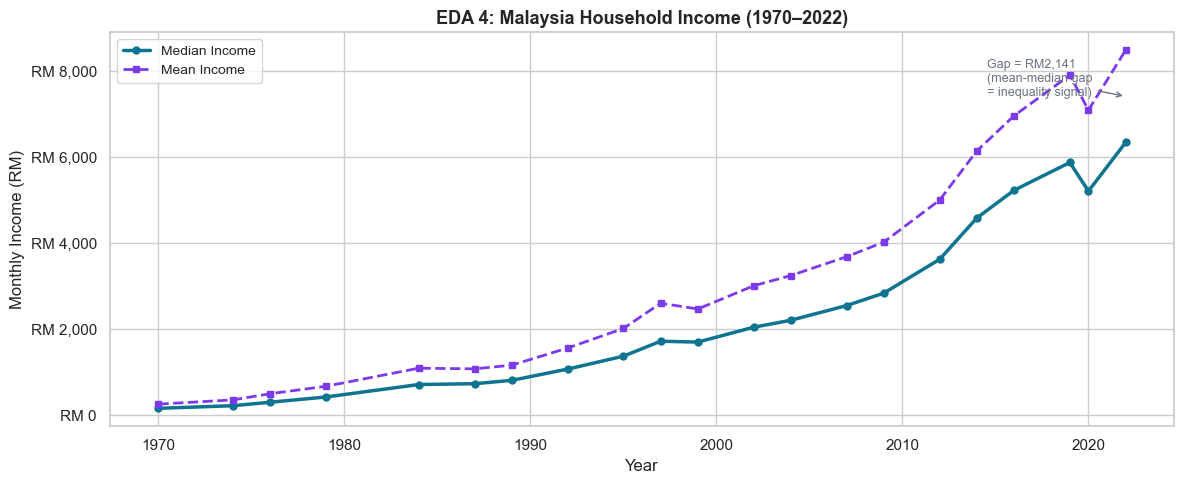

✅  Saved: outputs/eda04_income_growth.png
📌  Median income: RM166 (1970) → RM6,338 (2022) = +3718%


In [14]:
# ============================================================
# CELL 7D — EDA CHART 4: Household Income Growth
# ============================================================

if hh_income is not None:
    inc = hh_income.sort_values('year')

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(inc['year'], inc['income_median'],
            color='#0E7490', linewidth=2.5, label='Median Income', marker='o', markersize=5)
    ax.plot(inc['year'], inc['income_mean'],
            color='#7C3AED', linewidth=2, linestyle='--', label='Mean Income', marker='s', markersize=4)
    ax.set_title(f'EDA 4: Malaysia Household Income ({int(inc["year"].min())}–{int(inc["year"].max())})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Monthly Income (RM)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x:,.0f}'))
    ax.legend(fontsize=10)

    # Annotate gap between mean and median (inequality signal)
    last = inc.iloc[-1]
    gap  = last['income_mean'] - last['income_median']
    ax.annotate(f'Gap = RM{gap:,.0f}\n(mean-median gap\n= inequality signal)',
                xy=(last['year'], (last['income_mean'] + last['income_median']) / 2),
                xytext=(-100, 0), textcoords='offset points',
                fontsize=9, color='#6B7280',
                arrowprops=dict(arrowstyle='->', color='#6B7280'))

    plt.tight_layout()
    plt.savefig('../outputs/eda04_income_growth.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅  Saved: outputs/eda04_income_growth.png')
    first = inc.iloc[0]
    growth = ((last['income_median'] / first['income_median']) - 1) * 100
    print(f'📌  Median income: RM{first["income_median"]:,.0f} ({int(first["year"])}) → RM{last["income_median"]:,.0f} ({int(last["year"])}) = +{growth:.0f}%')


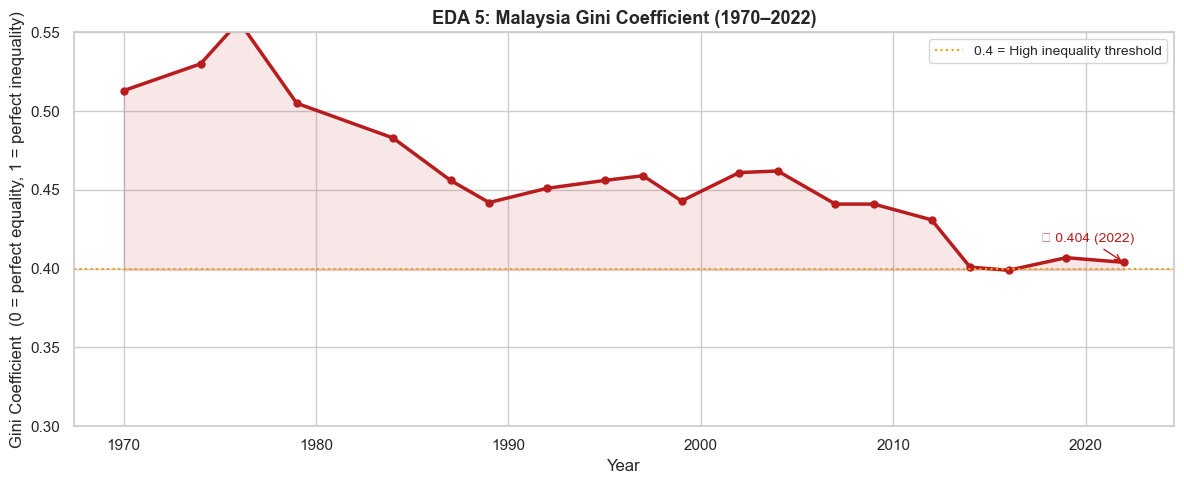

✅  Saved: outputs/eda05_gini_national.png


In [15]:
# ============================================================
# CELL 7E — EDA CHART 5: Gini Coefficient (National)
# ============================================================

if hh_inequality is not None:
    gini = hh_inequality.sort_values('year')

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(gini['year'], gini['gini'],
            color='#B91C1C', linewidth=2.5, marker='o', markersize=5)
    ax.fill_between(gini['year'], gini['gini'], gini['gini'].min(),
                    alpha=0.1, color='#B91C1C')

    # Reference lines
    ax.axhline(y=0.4, color='#F59E0B', linestyle=':', linewidth=1.5,
               label='0.4 = High inequality threshold')

    ax.set_title(f'EDA 5: Malaysia Gini Coefficient ({int(gini["year"].min())}–{int(gini["year"].max())})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Gini Coefficient  (0 = perfect equality, 1 = perfect inequality)')
    ax.set_ylim(0.3, 0.55)
    ax.legend(fontsize=10)

    first = gini.iloc[0]
    last  = gini.iloc[-1]
    direction = '📉' if last['gini'] < first['gini'] else '📈'
    ax.annotate(f'{direction} {last["gini"]:.3f} ({int(last["year"])})',
                xy=(last['year'], last['gini']),
                xytext=(-60, 15), textcoords='offset points',
                fontsize=10, color='#B91C1C',
                arrowprops=dict(arrowstyle='->', color='#B91C1C'))

    plt.tight_layout()
    plt.savefig('../outputs/eda05_gini_national.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅  Saved: outputs/eda05_gini_national.png')


cpi_annual columns: ['date', 'index', 'division', 'year']


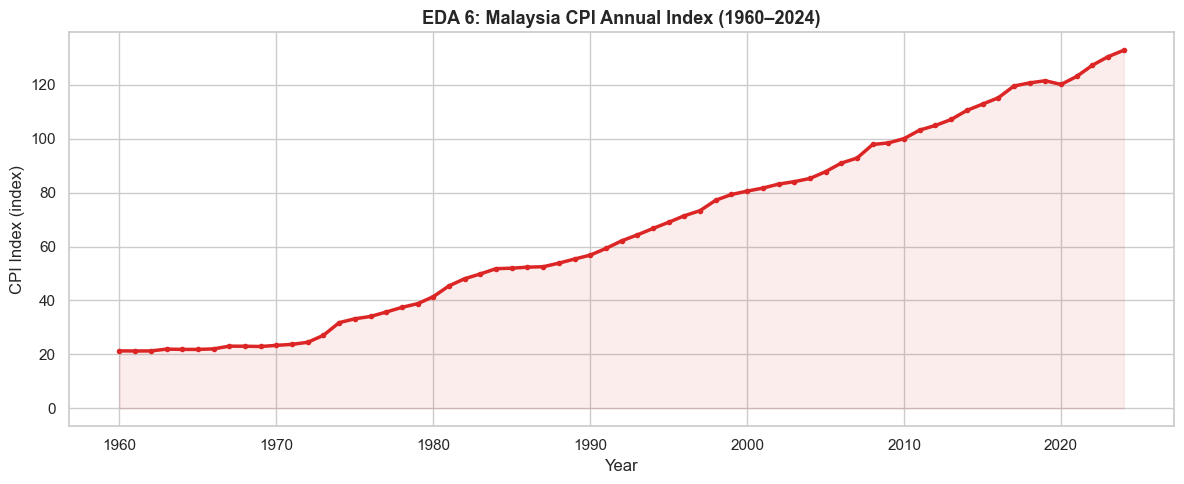

✅  Saved: outputs/eda06_cpi_annual.png


In [16]:
# ============================================================
# CELL 7F — EDA CHART 6: CPI Annual Trend
# Uses cpi_annual (long-run 1970–2024) for overview
# ============================================================

if cpi_annual is not None:
    cpi_a = cpi_annual.sort_values('year').copy()
    print(f'cpi_annual columns: {list(cpi_a.columns)}')

    # Detect value column (index or value or cpi)
    val_col = None
    for c in ['index', 'value', 'cpi', 'cpi_index']:
        if c in cpi_a.columns:
            val_col = c
            break
    if val_col is None:
        # Use first numeric column that isn't year
        for c in cpi_a.columns:
            if c != 'year' and pd.api.types.is_numeric_dtype(cpi_a[c]):
                val_col = c
                break

    if val_col:
        # Filter to overall/headline if division column exists
        if 'division' in cpi_a.columns:
            cpi_plot = cpi_a[cpi_a['division'] == 'overall'].copy() if 'overall' in cpi_a['division'].values else cpi_a.copy()
        else:
            cpi_plot = cpi_a.copy()

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(cpi_plot['year'], cpi_plot[val_col],
                color='#DC2626', linewidth=2.5, marker='o', markersize=3)
        ax.fill_between(cpi_plot['year'], cpi_plot[val_col],
                        alpha=0.08, color='#DC2626')
        ax.set_title(f'EDA 6: Malaysia CPI Annual Index ({int(cpi_plot["year"].min())}–{int(cpi_plot["year"].max())})',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel(f'CPI Index ({val_col})')
        plt.tight_layout()
        plt.savefig('../outputs/eda06_cpi_annual.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('✅  Saved: outputs/eda06_cpi_annual.png')
    else:
        print('⚠️  Could not detect CPI value column — skipping chart')
        print(f'   Columns available: {list(cpi_a.columns)}')


In [17]:
# ============================================================
# CELL 8 — DYNAMIC KEY INSIGHTS
# Reads from actual data — always accurate!
# ============================================================

lines = []
lines.append('=' * 66)
lines.append('  KEY INSIGHTS FROM EDA')
lines.append('=' * 66)

# ── Tema 1 Insights ──────────────────────────────────────────
lines.append('')
lines.append('  🏙  TEMA 1 — The Ageing Nation')
lines.append('  ' + '─' * 62)

if pop_malaysia is not None:
    pt = pop_malaysia[
        (pop_malaysia['age'] == 'overall') &
        (pop_malaysia['sex'] == 'both') &
        (pop_malaysia['ethnicity'] == 'overall')
    ].sort_values('year')
    f, l = pt.iloc[0], pt.iloc[-1]
    g = ((l['population'] / f['population']) - 1) * 100
    lines.append(f'  1. Population: {f["population"]:,.0f}k ({int(f["year"])}) → {l["population"]:,.0f}k ({int(l["year"])}) = +{g:.0f}% growth')

if fertility is not None:
    tfr_data = fertility[fertility['age_group'] == 'tfr'].sort_values('year')
    if len(tfr_data):
        lt = tfr_data.iloc[-1]
        status = 'BELOW replacement ⚠️' if lt['fertility_rate'] < 2.1 else 'above replacement ✅'
        lines.append(f'  2. TFR: {lt["fertility_rate"]:.2f} ({int(lt["year"])}) — {status} (threshold: 2.1)')

if births is not None and deaths is not None:
    b_last = births.sort_values('year').iloc[-1]
    d_last = deaths.sort_values('year').iloc[-1]
    b_val  = b_last['abs'] if 'abs' in b_last.index else None
    d_val  = d_last['abs'] if 'abs' in d_last.index else None
    if b_val and d_val:
        nat_growth = b_val - d_val
        lines.append(f'  3. Natural growth ({int(b_last["year"])}): {nat_growth:,.0f} people (births - deaths)')

# ── Tema 2 Insights ──────────────────────────────────────────
lines.append('')
lines.append('  💰  TEMA 2 — Income vs Inflation')
lines.append('  ' + '─' * 62)

if hh_income is not None:
    inc = hh_income.sort_values('year')
    f, l = inc.iloc[0], inc.iloc[-1]
    g = ((l['income_median'] / f['income_median']) - 1) * 100
    lines.append(f'  4. Median income: RM{f["income_median"]:,.0f} ({int(f["year"])}) → RM{l["income_median"]:,.0f} ({int(l["year"])}) = +{g:.0f}%')

if hh_inequality is not None:
    gini = hh_inequality.sort_values('year')
    f, l = gini.iloc[0], gini.iloc[-1]
    direction = 'IMPROVED 📉' if l['gini'] < f['gini'] else 'WORSENED 📈'
    lines.append(f'  5. Gini: {f["gini"]:.3f} ({int(f["year"])}) → {l["gini"]:.3f} ({int(l["year"])}) — {direction}')

if hh_poverty is not None:
    pov = hh_poverty.sort_values('year')
    f, l = pov.iloc[0], pov.iloc[-1]
    drop = f['poverty_absolute'] - l['poverty_absolute']
    lines.append(f'  6. Poverty: {f["poverty_absolute"]:.1f}% ({int(f["year"])}) → {l["poverty_absolute"]:.1f}% ({int(l["year"])}) — dropped {drop:.1f}pp 🎉')

if cpi_inflation is not None:
    cpi_ov = cpi_inflation[cpi_inflation['division'] == 'overall'] if 'division' in cpi_inflation.columns else cpi_inflation
    if 'inflation_yoy' in cpi_ov.columns:
        latest_yr   = cpi_ov['year'].max()
        avg_inf     = cpi_ov[cpi_ov['year'] == latest_yr]['inflation_yoy'].mean()
        lines.append(f'  7. Avg CPI inflation ({int(latest_yr)}): {avg_inf:.1f}% YoY (monthly headline, overall)')

# ── Combined Story ───────────────────────────────────────────
lines.append('')
lines.append('  🔗  COMBINED STORY')
lines.append('  ' + '─' * 62)
lines.append('  Malaysia is AGEING (TFR < 2.1, fewer babies) AND cost of')
lines.append('  living is RISING (CPI up, income gap persists).')
lines.append('  Young Malaysians face BOTH challenges simultaneously.')
lines.append('  This is the core narrative for the dashboard.')
lines.append('')
lines.append('=' * 66)

print('\n'.join(lines))


  KEY INSIGHTS FROM EDA

  🏙  TEMA 1 — The Ageing Nation
  ──────────────────────────────────────────────────────────────
  1. Population: 10,882k (1970) → 14,257k (1981) = +31% growth
  2. TFR: 1.73 (2023) — BELOW replacement ⚠️ (threshold: 2.1)
  3. Natural growth (2023): 258,796 people (births - deaths)

  💰  TEMA 2 — Income vs Inflation
  ──────────────────────────────────────────────────────────────
  4. Median income: RM166 (1970) → RM6,338 (2022) = +3718%
  5. Gini: 0.513 (1970) → 0.404 (2022) — IMPROVED 📉
  6. Poverty: 49.3% (1970) → 6.2% (2022) — dropped 43.1pp 🎉
  7. Avg CPI inflation (2026): 1.6% YoY (monthly headline, overall)

  🔗  COMBINED STORY
  ──────────────────────────────────────────────────────────────
  Malaysia is AGEING (TFR < 2.1, fewer babies) AND cost of
  living is RISING (CPI up, income gap persists).
  Young Malaysians face BOTH challenges simultaneously.
  This is the core narrative for the dashboard.



In [18]:
# ============================================================
# CELL 9 — SAVE ALL CLEAN DATASETS TO ../data/clean/
# After this, run 02_demographics_analysis.ipynb
# ============================================================

os.makedirs('../data/clean', exist_ok=True)

save_list = [
    ('population_malaysia',    pop_malaysia),
    ('population_state',       pop_state),
    ('population_district',    pop_district),
    ('fertility',              fertility),
    ('fertility_state',        fertility_state),
    ('births_annual',          births),
    ('deaths',                 deaths),
    ('marriages',              marriages),
    ('hh_profile',             hh_profile),
    ('hh_income',              hh_income),
    ('hh_income_state',        hh_income_state),
    ('hh_inequality',          hh_inequality),
    ('hh_inequality_state',    hh_inequality_state),
    ('hh_poverty',             hh_poverty),
    ('hh_poverty_state',       hh_poverty_state),
    ('hies_state',             hies_state),
    ('cpi_annual',             cpi_annual),
    ('cpi_headline',           cpi_headline),
    ('cpi_headline_inflation', cpi_inflation),
    ('cpi_state',              cpi_state),
    ('cpi_lowincome',          cpi_lowincome),
]

saved  = 0
failed = []

print('Saving clean datasets...')
print()

for name, df in save_list:
    if df is not None:
        path = f'../data/clean/{name}.csv'
        df.to_csv(path, index=False)
        print(f'  ✅  {name:<35} {len(df):>7,} rows  →  data/clean/')
        saved += 1
    else:
        print(f'  ❌  {name:<35} SKIPPED (not loaded)')
        failed.append(name)

print()
print('=' * 60)
print(f'  ✅  Saved  : {saved} / {len(save_list)} datasets')
if failed:
    print(f'  ❌  Skipped: {failed}')
    print()
    print('  FIX: Rerun 00_downloadDataFinal.ipynb, then rerun Cell 1 here.')
else:
    print()
    print('  🎉  ALL 21 CLEAN DATASETS SAVED!')

print()
print('=' * 60)
print()
print('📋  NEXT STEPS:')
print()
print('  ✅  00_downloadDataFinal.ipynb    — DONE')
print('  ✅  01_EDA_demographics.ipynb     — DONE  (this notebook)')
print()
print('  ▶️   02_demographics_analysis.ipynb')
print('       → Build all 12+ charts (Tema 1 + 2 + Gabungan)')
print('       → Charts saved to ../outputs/')
print()
print('  ▶️   03_dashboard.py (Streamlit) or Power BI / Tableau')
print('       → Load ../data/clean/ CSVs → interactive dashboard')


Saving clean datasets...

  ✅  population_malaysia                  92,000 rows  →  data/clean/
  ✅  population_state                    1,807,000 rows  →  data/clean/
  ✅  population_district                 10,567,000 rows  →  data/clean/
  ✅  fertility                               528 rows  →  data/clean/
  ✅  fertility_state                     2,280,000 rows  →  data/clean/
  ✅  births_annual                            24 rows  →  data/clean/
  ✅  deaths                                   24 rows  →  data/clean/
  ✅  marriages                                12 rows  →  data/clean/
  ✅  hh_profile                               19 rows  →  data/clean/
  ✅  hh_income                                21 rows  →  data/clean/
  ✅  hh_income_state                         303 rows  →  data/clean/
  ✅  hh_inequality                            20 rows  →  data/clean/
  ✅  hh_inequality_state                     273 rows  →  data/clean/
  ✅  hh_poverty                               20 rows  → 